In [1]:
import os
def get_paper_path(path=r"./media"):
    """
    功能：
        获取指定目录下paper地址
    参数：
        path:paper父目录
    返回值：
        参数paper绝对路径list
    """
    path_resolution = []
    for i in os.listdir(path):
        path_resolution.append(os.path.join(os.getcwd(),"media",i))
    return path_resolution
# print(get_paper_path())

-------------------

In [128]:
#核心
from collections import Counter
def statistics_of_font_size(page):
    """
    参数:page是单个fitz类对象，且为一页
    返回值:返回当前页出现最多的front size,及span对应的box坐标和文本
    """
    font_size =[]
    font_size_bbox = []
    font_size_text = []
    text_dict = page.get_text("dict")  # 获取文本信息字典
    for block in text_dict["blocks"]:  # 遍历每个文本块
        if block["type"] == 0:  # 如果是文字类型
            for line in block["lines"]:  # 遍历每一行
                for span in line["spans"]:  # 遍历每个span
                    font_size.append(span["size"])
                    font_size_bbox.append(span["bbox"])
                    font_size_text.append(span["text"])
#                     print(span)
#                     print(span["text"])
#                     print(span["size"])
#                     print(span["bbox"])
    
    return font_size,font_size_bbox,font_size_text


In [129]:
def test():
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        statistics_of_font_size(doc[i])
test()

In [83]:
import fitz
def find_main_text_font_size(path = r"./media/Financial Sector Taxation.pdf"):
    """
    功能：
        找正文font size，并返回
        
    参数：
        path
    返回值：
        正文font size
    """
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        font_size,_,_ = statistics_of_font_size(doc[i])
        record_most_account = record_most_account+list(font_size)
    print("全文span总量:",len(record_most_account))
    font_size_choice=sorted(dict(Counter(record_most_account)).items(), key=lambda x: x[1])[-1][0]
    print(Counter(record_most_account))
    #正文文本选择要设定一个阈值（经验判断可为-+2）
    print("全文频率最高span size:",font_size_choice)
    return font_size_choice

In [84]:
find_main_text_font_size()

全文span总量: 13246
Counter({12.0: 6158, 11.289799690246582: 1258, 10.979999542236328: 1249, 10.020000457763672: 800, 10.330300331115723: 535, 8.03653335571289: 234, 6.480000019073486: 224, 8.618040084838867: 191, 10.27779769897461: 158, 13.979999542236328: 151, 7.88590669631958: 145, 10.5: 134, 10.944698333740234: 131, 7.019999980926514: 127, 8.258000373840332: 125, 11.241949081420898: 112, 11.23289966583252: 98, 9.896682739257812: 97, 9.427000045776367: 93, 7.507500171661377: 90, 8.307048797607422: 89, 11.861000061035156: 89, 8.480850219726562: 88, 6.857100009918213: 86, 11.278844833374023: 83, 8.520000457763672: 77, 8.3909273147583: 56, 9.0: 47, 6.604400157928467: 45, 13.152700424194336: 36, 10.236998558044434: 34, 6.096499919891357: 32, 5.62939977645874: 32, 10.58509635925293: 30, 9.41779613494873: 28, 7.012899875640869: 28, 13.999899864196777: 25, 14.0: 24, 13.263099670410156: 20, 25.979999542236328: 19, 12.968113899230957: 18, 10.913700103759766: 16, 8.093700408935547: 14, 24.4426994

12.0

--------------------------------

In [74]:
#找正文
def find_main_text(path,main_text_font_size):
    """
    功能:
        通过比较font_size找正文
    参数:
        main_text_font_size是全文出现频率最高的font_size
    返回值:span字典
        主要要其中的text二号bbox关键字
        [{"text":''},{"bbox":[]}]
    """
    main_text_font_size = find_main_text_font_size()
    doc = fitz.open(path)
    
    all_page_main_text = []
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        
        per_page_main_text = []
        for block in text_dict["blocks"]:  # 遍历每个文本块
            if block["type"] == 0:  # 如果是文字类型
                for line in block["lines"]:  # 遍历每一行
                    for span in line["spans"]:  # 遍历每个span
#                         print(span["size"])
                        if span["size"]==main_text_font_size:
                            per_page_main_text.append(span)
        all_page_main_text.append(per_page_main_text)
    return all_page_main_text
main_text_font_size = find_main_text_font_size()
path=r"./media/Financial Sector Taxation.pdf"
find_main_text(path,main_text_font_size)                        

全文span总量: 13246
全文频率最高span size: 12.0
全文span总量: 13246
全文频率最高span size: 12.0


[[],
 [{'size': 12.0,
   'flags': 4,
   'font': 'TimesNewRomanPSMT',
   'color': 0,
   'ascender': 0.89111328125,
   'descender': -0.21630859375,
   'text': ' ',
   'origin': (306.0, 736.6799926757812),
   'bbox': (306.0, 725.9866333007812, 309.0, 739.2756958007812)},
  {'size': 12.0,
   'flags': 4,
   'font': 'TimesNewRomanPSMT',
   'color': 0,
   'ascender': 0.89111328125,
   'descender': -0.21630859375,
   'text': ' ',
   'origin': (79.20001220703125, 751.8599853515625),
   'bbox': (79.20001220703125,
    741.1666259765625,
    82.20001220703125,
    754.4556884765625)},
  {'size': 12.0,
   'flags': 4,
   'font': 'TimesNewRomanPSMT',
   'color': 0,
   'ascender': 0.89111328125,
   'descender': -0.21630859375,
   'text': ' ',
   'origin': (79.19999694824219, 624.719970703125),
   'bbox': (79.19999694824219,
    614.026611328125,
    82.19999694824219,
    627.315673828125)},
  {'size': 12.0,
   'flags': 4,
   'font': 'TimesNewRomanPSMT',
   'color': 0,
   'ascender': 0.89111328125,
 

有些text编码问题需要去解决
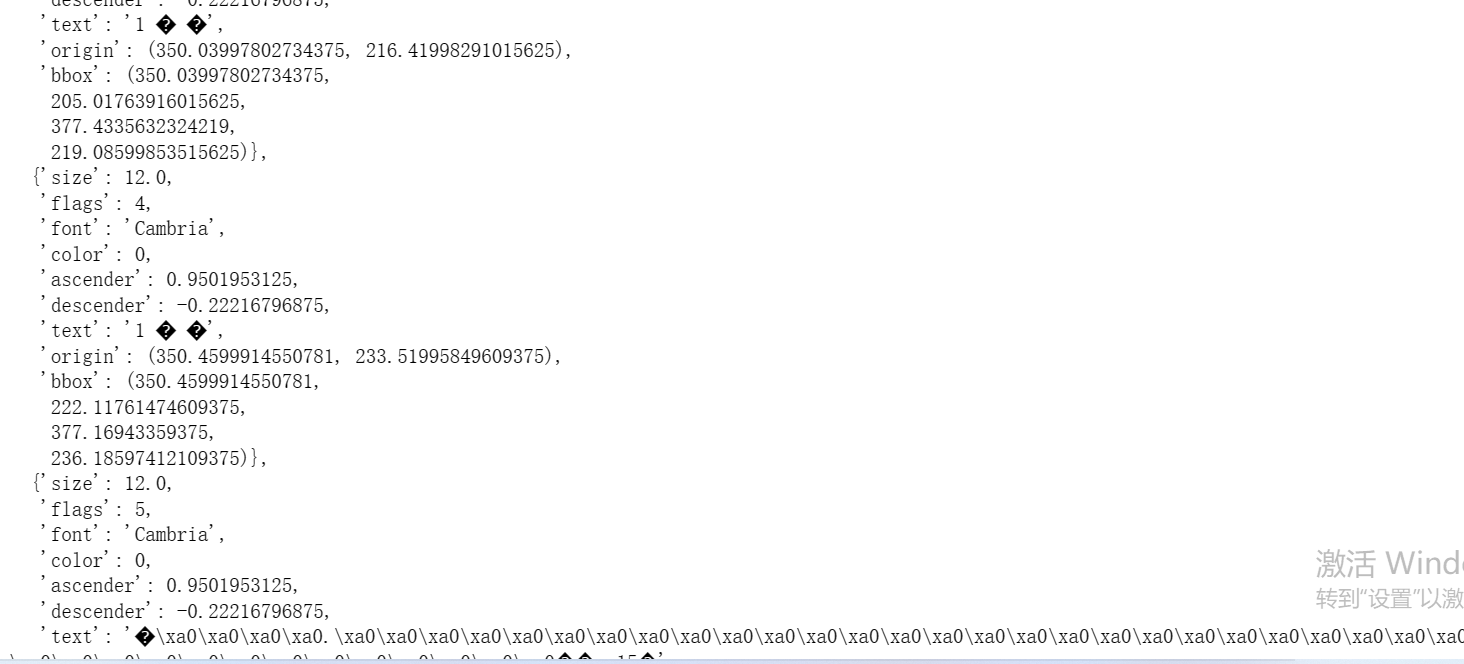

---------------------------------------

In [137]:
import fitz
def find_font_size_number_more_than_twice(path,main_text_font_size):
    """
    功能:统计font size出现次数>2的span
    思路:先获得全文span的font size再用Counter统计
    参数:
    返回值:
    """
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        font_size,_,_ = statistics_of_font_size(doc[i])
        record_most_account = record_most_account+list(font_size)
    print("全文span总量:",len(record_most_account))
    order_list = sorted(dict(Counter(record_most_account)).items(),key=lambda x:x[0],reverse=1)
#     print(order_list)
    new_order_list=[]
    for i,j in dict(order_list).items():
        if i>main_text_font_size and j>=2:
            new_order_list.append((i,j))
    return dict(new_order_list),record_most_account
font_size_dict,record_most_account= find_font_size_number_more_than_twice(path,find_main_text_font_size())
print(font_size_dict)

def recovery_order_via_dict(dict_1,font_size_list):
    """
    功能:通过字典做font size的list筛选，恢复全局顺序
    参数:字典和font size list
    返回值:
        顺序list
    """
    recovery_list = []
    for i in font_size_list:
        if i in dict_1.keys():
            recovery_list.append(i)
    return recovery_list

R_list = recovery_order_via_dict(font_size_dict,record_most_account)
#去重判断是否满足树结构
new_list = []
for eleme in R_list:
    if eleme not in new_list:
        new_list.append(eleme)
new_list#去重后的list，每个元素可以视为表示一行


全文span总量: 13246
Counter({12.0: 6158, 11.289799690246582: 1258, 10.979999542236328: 1249, 10.020000457763672: 800, 10.330300331115723: 535, 8.03653335571289: 234, 6.480000019073486: 224, 8.618040084838867: 191, 10.27779769897461: 158, 13.979999542236328: 151, 7.88590669631958: 145, 10.5: 134, 10.944698333740234: 131, 7.019999980926514: 127, 8.258000373840332: 125, 11.241949081420898: 112, 11.23289966583252: 98, 9.896682739257812: 97, 9.427000045776367: 93, 7.507500171661377: 90, 8.307048797607422: 89, 11.861000061035156: 89, 8.480850219726562: 88, 6.857100009918213: 86, 11.278844833374023: 83, 8.520000457763672: 77, 8.3909273147583: 56, 9.0: 47, 6.604400157928467: 45, 13.152700424194336: 36, 10.236998558044434: 34, 6.096499919891357: 32, 5.62939977645874: 32, 10.58509635925293: 30, 9.41779613494873: 28, 7.012899875640869: 28, 13.999899864196777: 25, 14.0: 24, 13.263099670410156: 20, 25.979999542236328: 19, 12.968113899230957: 18, 10.913700103759766: 16, 8.093700408935547: 14, 24.4426994

```
问题:
    大概率文章第一个font size不是一定是目录例如下面输出。取第一个最大值作为树的root比较合理

 [14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 35.9999885559082,
 35.9999885559082,
 35.9999885559082,
 30.0,
 30.0,
 30.0,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 22.020000457763672,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 16.020000457763672,
 25.979999542236328,
 25.979999542236328,
 25.979999542236328,
 25.979999542236328,
 16.020000457763672,
 16.020000457763672,
 13.979999542236328,
 16.020000457763672,
 16.020000457763672,
 16.020000457763672,
 16.020000457763672,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.152700424194336,
 24.442699432373047,
 24.442699432373047,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 24.442699432373047,
 24.442699432373047,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 24.442699432373047,
 24.442699432373047,
 24.442699432373047,
 24.442699432373047,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 24.442699432373047,
 24.442699432373047,
 24.442699432373047,
 24.442699432373047,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.152700424194336,
 13.979999542236328,
 25.979999542236328,
 25.979999542236328,
 25.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.979999542236328,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.263099670410156,
 13.979999542236328,
 12.833200454711914,
 13.999899864196777,
 13.999899864196777,
 13.999899864196777,
 13.999899864196777]
```

In [133]:
def judge_if_list_is_full_tree(sorted_list):
    """
    功能:判断是否一棵完备树
    参数:
        sorted_list:从大到小排好的list
    返回值:
        True or False :Yes or No
    """

    # 完全二叉树的特点是：除了最后一层，其他层的节点数都是满的，最后一层的节点都靠左排列

    # 获取列表长度
    n = len(sorted_list)

    # 遍历除最后一个元素外的其他元素
    for i in range(n - 1):
        # 如果当前节点的值小于等于下一个节点的值，则不是完全二叉树
        if sorted_list[i] <= sorted_list[i + 1]:
            return False

    # 判断最后一个节点是否满足完全二叉树的要求
    for i in range(n // 2):
        left_child_index = 2 * i + 1
        right_child_index = 2 * i + 2

        # 如果左孩子存在且大于当前节点的值，或者右孩子存在且大于当前节点的值，则不是完全二叉树
        if (left_child_index < n and sorted_list[i] < sorted_list[left_child_index]) or \
                (right_child_index < n and sorted_list[i] < sorted_list[right_child_index]):
            return False

    return True


def find_TOC(path):
    """
    功能:
        没有TOC情况下找目录
        1.所有 font size > 正文的 font size，并且出现次数 >= 2 的认为是目录(先统计目前哪些span的font size出现次数超过2次)
        2.按照 font size 从大到小排序，是否能形成一颗完备的树
    参数:
        
    返回值:
        
    """
    doc =fitz.open(path)
    main_text_font_size= find_main_text_font_size()
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        for block in text_dict["blocks"]:  # 遍历每个文本块
            if block["type"] == 0:  # 如果是文字类型
                for line in block["lines"]:  # 遍历每一行
                    for span in line["spans"]:  # 遍历每个span
#                         print(span["size"])
                        if span["size"]>main_text_font_size:
                            per_page_main_text.append(span)
                
        all_page_main_text.append(per_page_main_text)
    return all_page_main_text
# if doc.get_toc() != []:
#     print(doc.get_toc())
# else:    
